In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [2]:
df = pd.read_excel('/content/worker_health_dataset.xlsx')

In [3]:
df.head()

,worker_id,age,department,shift_duration_hrs,reported_symptoms,diagnosis,ppe_compliance_score,audio_alert_flag,risk_level,outcome
0,W1000,48,Paint Shop,7.4,minor knee pain after long standing shift,Dehydration (mild),0.79,0,LOW,First Aid
1,W1001,51,Boiler Room,6.2,"occasional dizziness, light sensitivity",Dehydration (mild),0.73,0,LOW,Rest and Resume
2,W1002,31,Assembly Line,8.7,"muscle soreness, mild back ache",Mild Allergic Reaction,0.94,0,LOW,First Aid
3,W1003,58,Heavy Machinery,8.8,minor knee pain after long standing shift,Mild Allergic Reaction,0.91,0,LOW,No Treatment Required
4,W1004,54,Boiler Room,12.2,"heat stroke symptoms, no sweating, skin hot an...",Heat Stroke,0.33,1,HIGH,ICU Admission


In [4]:
df.isnull().sum()

,0
worker_id,0
age,0
department,0
shift_duration_hrs,0
reported_symptoms,0
diagnosis,0
ppe_compliance_score,0
audio_alert_flag,0
risk_level,0
outcome,0


In [5]:
df.dropna(inplace=True)

In [6]:
features = [
    'age',
    'department',
    'shift_duration_hrs',
    'reported_symptoms',
    'ppe_compliance_score',
    'audio_alert_flag'
]

target = 'risk_level'

df = df[features + [target]]

In [7]:
label_encoder = LabelEncoder()

df[target] = label_encoder.fit_transform(df[target])

df.head()

,age,department,shift_duration_hrs,reported_symptoms,ppe_compliance_score,audio_alert_flag,risk_level
0,48,Paint Shop,7.4,minor knee pain after long standing shift,0.79,0,1
1,51,Boiler Room,6.2,"occasional dizziness, light sensitivity",0.73,0,1
2,31,Assembly Line,8.7,"muscle soreness, mild back ache",0.94,0,1
3,58,Heavy Machinery,8.8,minor knee pain after long standing shift,0.91,0,1
4,54,Boiler Room,12.2,"heat stroke symptoms, no sweating, skin hot an...",0.33,1,0


In [8]:
tfidf = TfidfVectorizer(max_features=100)

text_features = tfidf.fit_transform(
    df['reported_symptoms']
).toarray()

In [9]:
structured_df = df.drop(
    columns=['reported_symptoms', 'risk_level']
)

In [10]:
structured_df = pd.get_dummies(structured_df)

structured_df.head()

,age,shift_duration_hrs,ppe_compliance_score,audio_alert_flag,department_Assembly Line,department_Boiler Room,department_Chemical Processing,department_Electrical Unit,department_Foundry,department_Heavy Machinery,department_Mining Section,department_Paint Shop,department_Warehouse,department_Welding Unit
0,48,7.4,0.79,0,False,False,False,False,False,False,False,True,False,False
1,51,6.2,0.73,0,False,True,False,False,False,False,False,False,False,False
2,31,8.7,0.94,0,True,False,False,False,False,False,False,False,False,False
3,58,8.8,0.91,0,False,False,False,False,False,True,False,False,False,False
4,54,12.2,0.33,1,False,True,False,False,False,False,False,False,False,False


In [11]:
scaler = StandardScaler()

structured_scaled = scaler.fit_transform(structured_df)

In [12]:
X = np.hstack((structured_scaled, text_features))

y = df[target]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        94
           2       1.00      1.00      1.00        78

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [18]:
print(confusion_matrix(y_test, y_pred))

[[28  0  0]
 [ 0 94  0]
 [ 0  0 78]]


In [19]:
joblib.dump(model, 'risk_prediction_model.pkl')

joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

joblib.dump(scaler, 'scaler.pkl')

joblib.dump(label_encoder, 'label_encoder.pkl')

['label_encoder.pkl']

In [31]:
joblib.dump(
    structured_df.columns.tolist(),
    'feature_columns.pkl'
)

['feature_columns.pkl']

In [20]:
sample_text = ["worker experiencing chest pain and dizziness"]

sample_text_vector = tfidf.transform(sample_text).toarray()

In [21]:
sample_structured = structured_df.iloc[0:1]

sample_structured_scaled = scaler.transform(sample_structured)

In [22]:
final_input = np.hstack(
    (
        sample_structured_scaled,
        sample_text_vector
    )
)

In [23]:
prediction = model.predict(final_input)

predicted_label = label_encoder.inverse_transform(prediction)

print("Predicted Risk Level :", predicted_label[0])

Predicted Risk Level : LOW


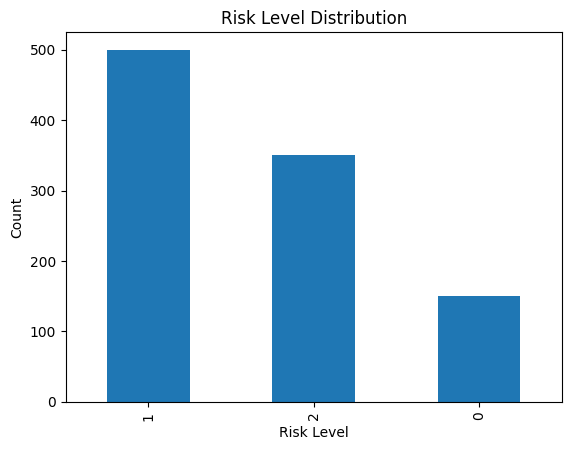

In [24]:
import matplotlib.pyplot as plt

df['risk_level'].value_counts().plot(kind='bar')

plt.title("Risk Level Distribution")

plt.xlabel("Risk Level")

plt.ylabel("Count")

plt.show()

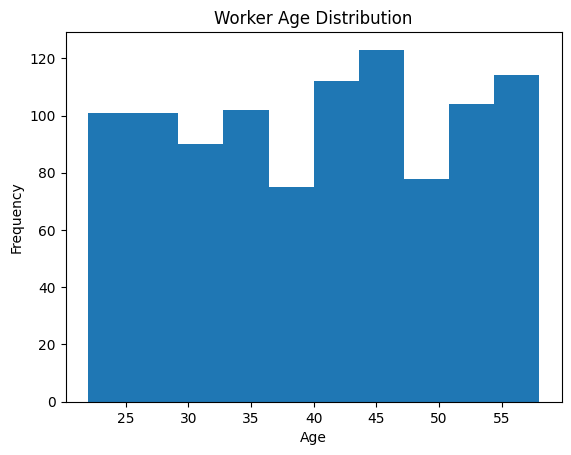

In [25]:
plt.hist(df['age'], bins=10)

plt.title("Worker Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

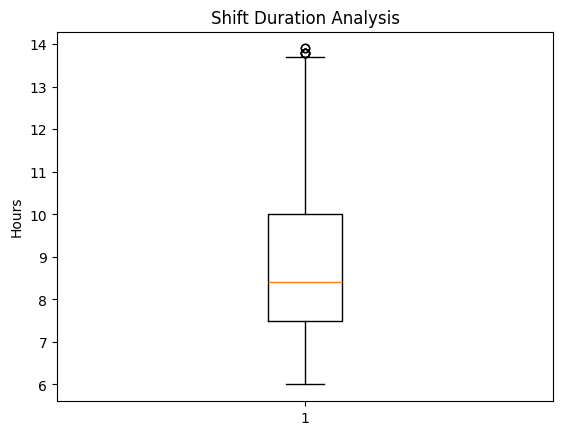

In [26]:
plt.boxplot(df['shift_duration_hrs'])

plt.title("Shift Duration Analysis")

plt.ylabel("Hours")

plt.show()

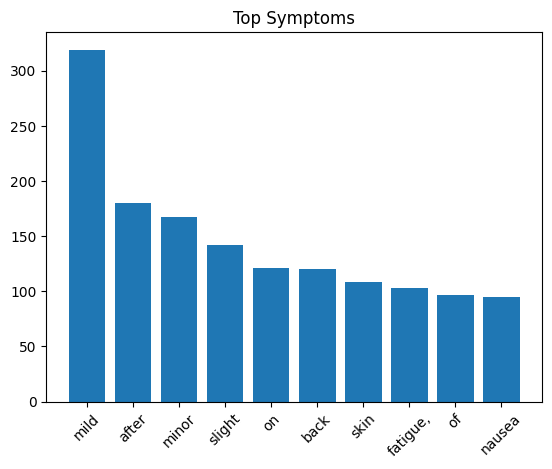

In [27]:
from collections import Counter

all_text = " ".join(df['reported_symptoms'])

words = all_text.split()

common_words = Counter(words).most_common(10)

words = [i[0] for i in common_words]

counts = [i[1] for i in common_words]

plt.bar(words, counts)

plt.title("Top Symptoms")

plt.xticks(rotation=45)

plt.show()

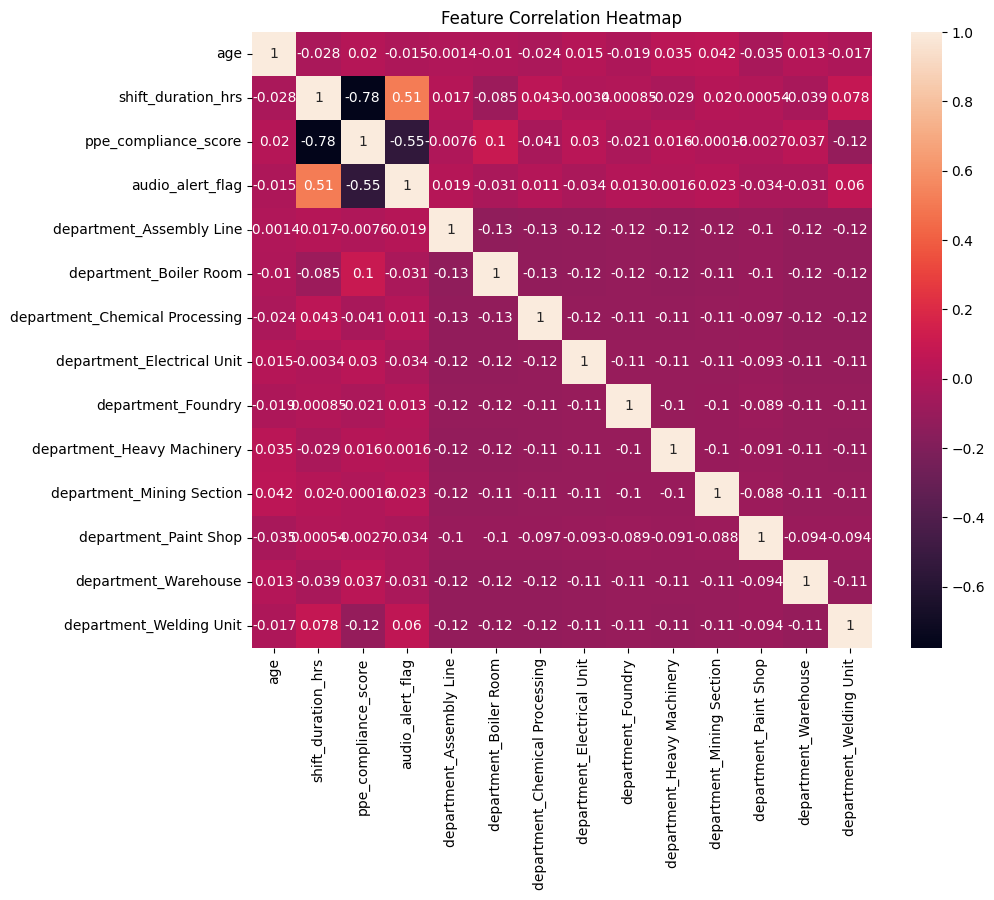

In [28]:
import seaborn as sns

corr = structured_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("RF Accuracy:",
      accuracy_score(y_test, rf_pred))

RF Accuracy: 1.0


In [30]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGB Accuracy:",
      accuracy_score(y_test, xgb_pred))

XGB Accuracy: 1.0
